# 01 — Data Exploration

This notebook explores the RadioML2018.01A dataset used in AMCShield.

The dataset contains complex-valued communication signals represented using
in-phase (I) and quadrature (Q) components.

We examine:

- Dataset structure
- Number of samples
- Modulation classes
- SNR distribution
- Signal representation
- Example I/Q waveforms
- Clean classification accuracy across SNR levels


In [1]:
from pathlib import Path
import json
import yaml
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

CONFIG_PATH = ROOT / "config.yaml"
DATA_PATH = ROOT / "data/raw/GOLD_XYZ_OSC.0001_1024.hdf5"
CLASSES_PATH = ROOT / "data/raw/classes-fixed.json"
RESULTS = ROOT / "results"

print("Project root:", ROOT)
print("Dataset:", DATA_PATH)

Project root: d:\MediCaps University\7 SEM\Project 1\AMCShield
Dataset: d:\MediCaps University\7 SEM\Project 1\AMCShield\data\raw\GOLD_XYZ_OSC.0001_1024.hdf5


In [2]:
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

print("Dataset:", config["dataset"]["name"])
print("Number of classes:", config["dataset"]["num_classes"])
print("Signal length:", config["dataset"]["signal_length"])
print("SNR range:", config["dataset"]["snr_range"])
print("SNR step:", config["dataset"]["snr_step"])

FileNotFoundError: [Errno 2] No such file or directory: 'd:\\MediCaps University\\7 SEM\\Project 1\\AMCShield\\config.yaml'

In [ ]:
with h5py.File(DATA_PATH, "r") as f:
    print("Datasets:")
    for key in f.keys():
        print(f"  {key}: shape={f[key].shape}, dtype={f[key].dtype}")

In [3]:
with open(CLASSES_PATH, "r", encoding="utf-8") as f:
    classes = json.load(f)

print("Number of classes:", len(classes))

for i, cls in enumerate(classes):
    print(i, cls)

Number of classes: 24
0 OOK
1 4ASK
2 8ASK
3 BPSK
4 QPSK
5 8PSK
6 16PSK
7 32PSK
8 16APSK
9 32APSK
10 64APSK
11 128APSK
12 16QAM
13 32QAM
14 64QAM
15 128QAM
16 256QAM
17 AM-SSB-WC
18 AM-SSB-SC
19 AM-DSB-WC
20 AM-DSB-SC
21 FM
22 GMSK
23 OQPSK


In [4]:
with h5py.File(DATA_PATH, "r") as f:
    z = f["Z"][:].reshape(-1)

unique_snr, counts = np.unique(z, return_counts=True)

snr_df = pd.DataFrame({
    "SNR": unique_snr.astype(int),
    "Samples": counts
})

display(snr_df)

,SNR,Samples
0,-20,98304
1,-18,98304
2,-16,98304
3,-14,98304
4,-12,98304
5,-10,98304
6,-8,98304
7,-6,98304
8,-4,98304
9,-2,98304


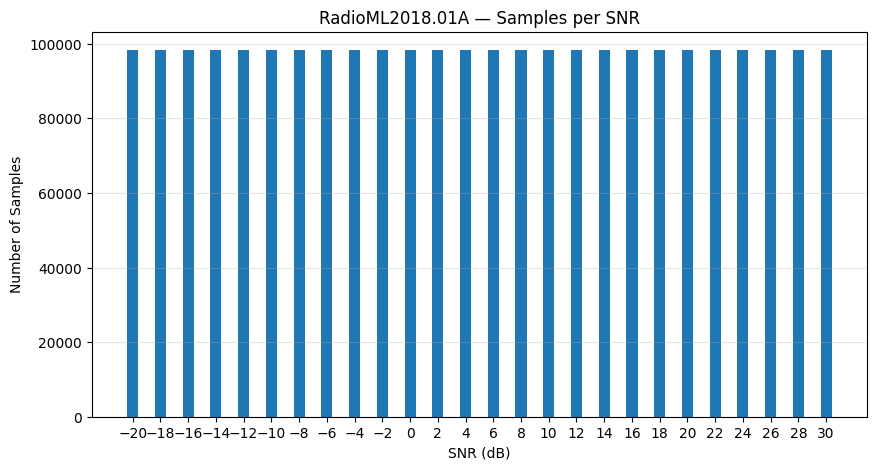

In [5]:
plt.figure(figsize=(10, 5))
plt.bar(snr_df["SNR"], snr_df["Samples"])
plt.xlabel("SNR (dB)")
plt.ylabel("Number of Samples")
plt.title("RadioML2018.01A — Samples per SNR")
plt.xticks(unique_snr)
plt.grid(axis="y", alpha=0.3)
plt.show()

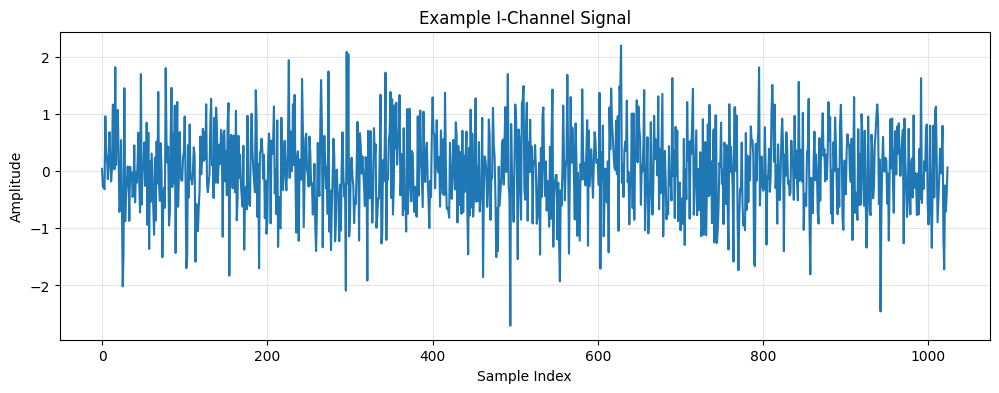

In [6]:
with h5py.File(DATA_PATH, "r") as f:
    sample = f["X"][0]

signal = sample[:, 0]

plt.figure(figsize=(12, 4))
plt.plot(signal)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.title("Example I-Channel Signal")
plt.grid(alpha=0.3)
plt.show()

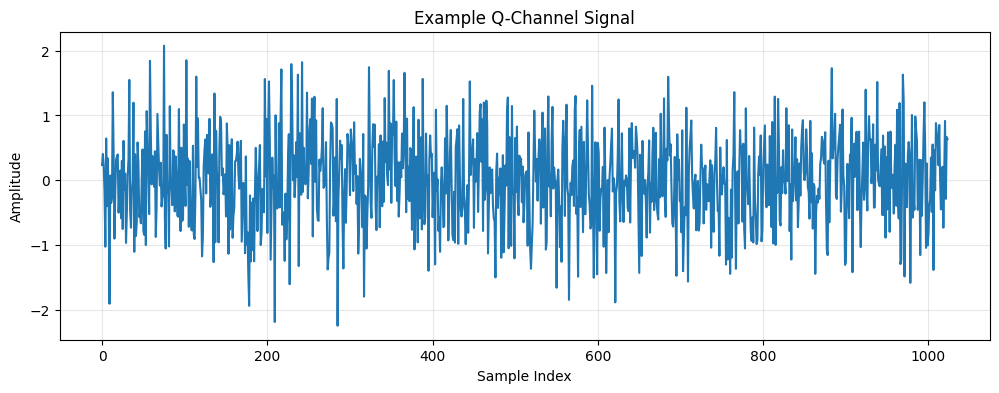

In [7]:
signal_q = sample[:, 1]

plt.figure(figsize=(12, 4))
plt.plot(signal_q)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.title("Example Q-Channel Signal")
plt.grid(alpha=0.3)
plt.show()

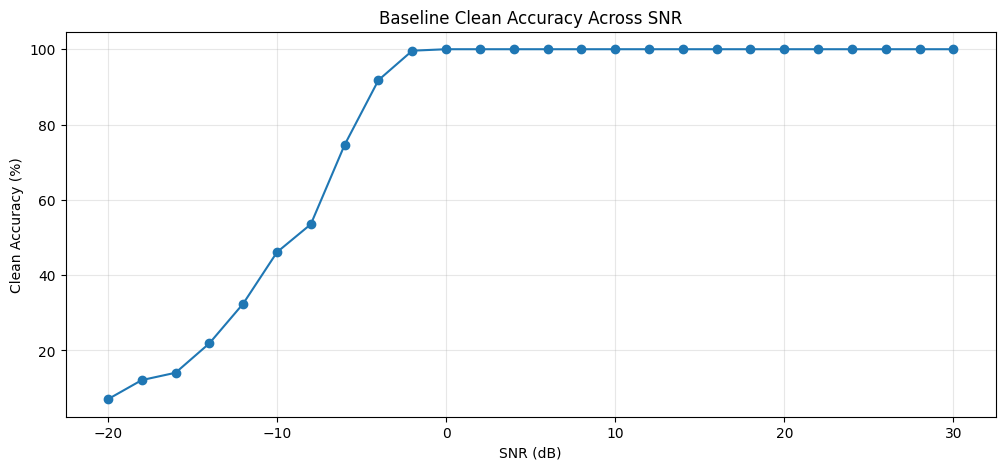

In [8]:
clean = pd.read_csv(RESULTS / "baseline_clean_results.csv")

plt.figure(figsize=(12, 5))
plt.plot(clean["snr"], clean["clean_accuracy"], marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Clean Accuracy (%)")
plt.title("Baseline Clean Accuracy Across SNR")
plt.grid(alpha=0.3)
plt.show()